<a href="https://colab.research.google.com/github/harshitha3506/deeplearning/blob/main/DLSECONDHALF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Q1. Pretrained models

LeNet

In [ ]:
import keras
from keras import datasets
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, Flatten, Dense

(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

x_train = x_train/255.0
x_test = x_test/255.0

x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

y_train = keras.utils.to_categorical(y_train,10)
y_test = keras.utils.to_categorical(y_test,10)

model = Sequential([
    Conv2D(6,(5,5),activation='tanh',input_shape=(28,28,1)),
    AveragePooling2D((2,2)),
    Conv2D(16,(5,5),activation='tanh'),
    AveragePooling2D((2,2)),
    Flatten(),
    Dense(120,activation='tanh'),
    Dense(84,activation='tanh'),
    Dense(10,activation='softmax')
])

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.fit(x_train,y_train,epochs=3,batch_size=128)
print(model.evaluate(x_test,y_test))

Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 77ms/step - accuracy: 0.8928 - loss: 0.3708
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.9614 - loss: 0.1285
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.9749 - loss: 0.0826
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9773 - loss: 0.0708
[0.07077660411596298, 0.9772999882698059]


AlexNet

In [ ]:
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(-1,28,28,1)/255.0
x_test  = x_test.reshape(-1,28,28,1)/255.0

y_train = keras.utils.to_categorical(y_train,10)
y_test  = keras.utils.to_categorical(y_test,10)

# simplified AlexNet
model = Sequential([
    Conv2D(64,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(256,(3,3),activation='relu'),

    Flatten(),
    Dense(256,activation='relu'),
    Dropout(0.5),

    Dense(10,activation='softmax')
])

model.compile('adam','categorical_crossentropy',metrics=['accuracy'])
model.fit(x_train,y_train,epochs=3,batch_size=128)

print(model.evaluate(x_test,y_test))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - accuracy: 0.9404 - loss: 0.1906
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9853 - loss: 0.0502
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9897 - loss: 0.0346
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9917 - loss: 0.0262
[0.0262162908911705, 0.9916999936103821]


ZFNet

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(96,(7,7),strides=2,activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(2,2),

    Conv2D(256,(5,5),activation='relu',padding='same'),
    MaxPooling2D(2,2),

    Conv2D(384,(3,3),activation='relu',padding='same'),

    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train,y_train,epochs=3)

print(model.evaluate(x_test, y_test))

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9570 - loss: 0.1355
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9871 - loss: 0.0461
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9899 - loss: 0.0350
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9855 - loss: 0.0546
[0.05461350083351135, 0.9854999780654907]


VGGNet

In [ ]:
import keras, tensorflow as tf
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Flatten, Dense
from tensorflow.keras.applications import VGG16

# data
(x_train,y_train),(x_test,y_test) = mnist.load_data()
x_train = x_train.reshape(-1,28,28,1)/255.0
x_test  = x_test.reshape(-1,28,28,1)/255.0

# resize + RGB
x_train = tf.image.resize(x_train,(32,32))
x_test  = tf.image.resize(x_test,(32,32))
x_train = tf.repeat(x_train,3,axis=-1)
x_test  = tf.repeat(x_test,3,axis=-1)

y_train = keras.utils.to_categorical(y_train,10)
y_test  = keras.utils.to_categorical(y_test,10)

# model
base = VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3))

model = Sequential([
    base,
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])

model.compile('adam','categorical_crossentropy',metrics=['accuracy'])
model.fit(x_train,y_train,epochs=3)
print(model.evaluate(x_test,y_test))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 115s 52ms/step - accuracy: 0.8655 - loss: 0.4152
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 134s 52ms/step - accuracy: 0.9758 - loss: 0.1061
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 94s 50ms/step - accuracy: 0.9809 - loss: 0.0873
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9859 - loss: 0.0647
[0.06472424417734146, 0.9858999848365784]


GoogleLeNet

In [ ]:
import keras, tensorflow as tf
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Flatten, Dense
from tensorflow.keras.applications import InceptionV3

# data
(x_train,y_train),(x_test,y_test) = mnist.load_data()
x_train = x_train.reshape(-1,28,28,1)/255.0
x_test  = x_test.reshape(-1,28,28,1)/255.0

# resize + RGB
x_train = tf.image.resize(x_train,(75,75))
x_test  = tf.image.resize(x_test,(75,75))
x_train = tf.repeat(x_train,3,axis=-1)
x_test  = tf.repeat(x_test,3,axis=-1)

y_train = keras.utils.to_categorical(y_train,10)
y_test  = keras.utils.to_categorical(y_test,10)

# model
base = InceptionV3(weights='imagenet', include_top=False, input_shape=(75,75,3))

model = Sequential([
    base,
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])

model.compile('adam','categorical_crossentropy',metrics=['accuracy'])
model.fit(x_train,y_train,epochs=3)
print(model.evaluate(x_test,y_test))

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 155s 48ms/step - accuracy: 0.9516 - loss: 0.2032
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 89s 48ms/step - accuracy: 0.9795 - loss: 0.0810
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 92s 49ms/step - accuracy: 0.9844 - loss: 0.0624
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.9899 - loss: 0.0338
[0.03379078954458237, 0.9898999929428101]


Resnet

In [ ]:
import keras, tensorflow as tf
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Flatten, Dense
from tensorflow.keras.applications import ResNet50

# data
(x_train,y_train),(x_test,y_test) = mnist.load_data()
x_train = x_train.reshape(-1,28,28,1)/255.0
x_test  = x_test.reshape(-1,28,28,1)/255.0

# resize + RGB
x_train = tf.image.resize(x_train,(32,32))
x_test  = tf.image.resize(x_test,(32,32))
x_train = tf.repeat(x_train,3,axis=-1)
x_test  = tf.repeat(x_test,3,axis=-1)

y_train = keras.utils.to_categorical(y_train,10)
y_test  = keras.utils.to_categorical(y_test,10)

# model
base = ResNet50(weights='imagenet', include_top=False, input_shape=(32,32,3))

model = Sequential([
    base,
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])

model.compile('adam','categorical_crossentropy',metrics=['accuracy'])
model.fit(x_train,y_train,epochs=3)
print(model.evaluate(x_test,y_test))

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 104s 28ms/step - accuracy: 0.9459 - loss: 0.2330
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9750 - loss: 0.1051
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9819 - loss: 0.0783
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9812 - loss: 0.0719
[0.07187866419553757, 0.9811999797821045]


Q2. Visualizing Convolutional Neural Networks

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


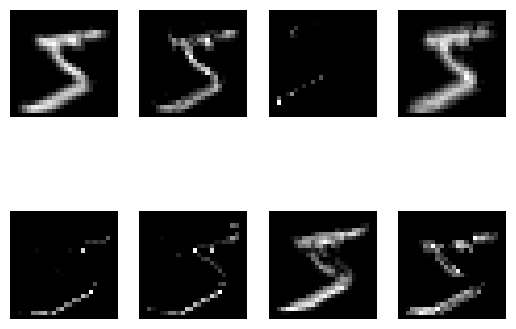

In [ ]:
import keras
from keras import datasets
from keras.models import Model
from keras.layers import Conv2D, MaxPooling2D, Input
import matplotlib.pyplot as plt

# load data
(x_train, _), _ = datasets.mnist.load_data()
x_train = x_train/255.0
x_train = x_train.reshape(-1,28,28,1)

# define model using Functional API
input_layer = Input(shape=(28,28,1))
x = Conv2D(8,(3,3),activation='relu')(input_layer)
x = MaxPooling2D((2,2))(x)
x = Conv2D(16,(3,3),activation='relu')(x)

model = Model(inputs=input_layer, outputs=x)

# now extract feature maps from the first Conv2D layer
layer_model = Model(inputs=model.input, outputs=model.layers[1].output)

# pick image
img = x_train[0].reshape(1,28,28,1)

# get feature maps
feature_maps = layer_model.predict(img)

# plot
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(feature_maps[0,:,:,i], cmap='gray')
    plt.axis('off')

plt.show()


Q3. Guided Backpropagation to discover which input pixels influence the perceptron.

469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - loss: 0.3797


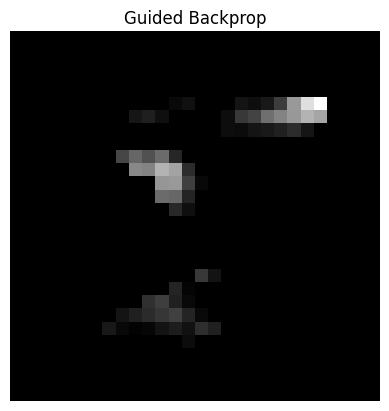

In [ ]:
import tensorflow as tf
import keras
from keras import datasets
from keras.models import Sequential
from keras.layers import Conv2D, Flatten, Dense
import matplotlib.pyplot as plt

# load data
(x_train, y_train), _ = datasets.mnist.load_data()
x_train = x_train/255.0
x_train = x_train.reshape(-1,28,28,1)

# simple model
model = Sequential([
    keras.layers.Input(shape=(28,28,1)),
    Conv2D(8,(3,3),activation='relu'),
    Flatten(),
    Dense(10,activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
model.fit(x_train, y_train, epochs=1, batch_size=128)

# pick one image
img = tf.convert_to_tensor(x_train[0:1])

# guided backprop
with tf.GradientTape() as tape:
    tape.watch(img)
    preds = model(img)
    loss = preds[:, tf.argmax(preds[0])]

grads = tape.gradient(loss, img)

# keep only positive gradients
# guided_grads = tf.maximum(grads, 0)
guided_grads = grads * tf.cast(grads > 0, grads.dtype) * tf.cast(img > 0, grads.dtype)

# show result
plt.imshow(guided_grads[0,:,:,0], cmap='gray')
plt.title("Guided Backprop")
plt.axis('off')
plt.show()

Q4. Implement Auto Encoder model on MINIST dataset.

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.2443
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1433
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1182
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.1043
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0953
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


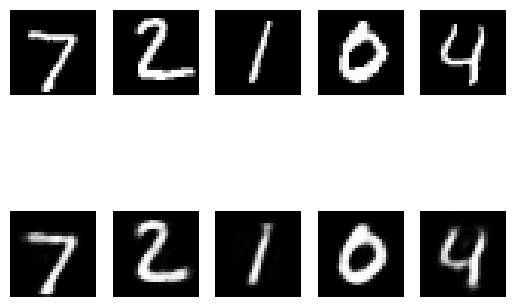

In [ ]:
import keras
from keras.datasets import mnist
from keras.layers import Input, Dense
from keras.models import Model
import matplotlib.pyplot as plt

# data
(x_train,_),(x_test,_) = mnist.load_data()
x_train = x_train.reshape(-1,784)/255.0
x_test  = x_test.reshape(-1,784)/255.0

# model
inp = Input(shape=(784,))
encoded = Dense(64, activation='relu')(inp)
decoded = Dense(784, activation='sigmoid')(encoded)

model = Model(inp, decoded)
model.compile('adam','binary_crossentropy')

# train
model.fit(x_train, x_train, epochs=5, batch_size=256)

# predict
res = model.predict(x_test[:5])

# show
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    plt.subplot(2,5,i+6)
    plt.imshow(res[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

Q5. a. Implement Undercomplete AE

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 0.2227
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.1242
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1074
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0995
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0944


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


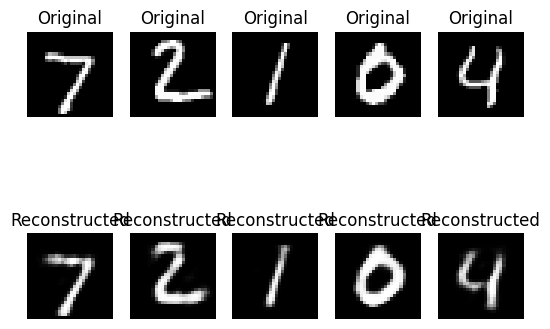

In [ ]:
import keras
from keras import datasets
from keras.models import Model
from keras.layers import Input, Dense
import matplotlib.pyplot as plt

# data
(x_train,_),(x_test,_) = datasets.mnist.load_data()
x_train = x_train.reshape(-1,784)/255.0
x_test  = x_test.reshape(-1,784)/255.0

# model
inp = Input(shape=(784,))
x = Dense(128, activation='relu')(inp)
latent = Dense(64, activation='relu')(x)   # bottleneck (smaller)

x = Dense(128, activation='relu')(latent)
out = Dense(784, activation='sigmoid')(x)

model = Model(inp, out)
model.compile('adam','binary_crossentropy')

# train
model.fit(x_train, x_train, epochs=5, batch_size=256)

# predict
res = model.predict(x_test[:5])

# visualize
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(2,5,i+6)
    plt.imshow(res[i].reshape(28,28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

Q5. b. Overcomplete AE

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 17s 66ms/step - loss: 0.1557
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - loss: 0.0843
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 16s 70ms/step - loss: 0.0768
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 16s 67ms/step - loss: 0.0734
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 30s 108ms/step - loss: 0.0716


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


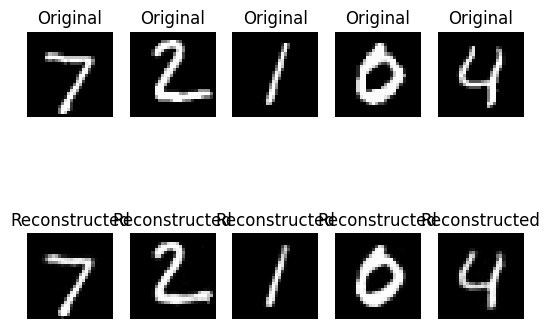

In [ ]:
import keras
from keras import datasets
from keras.models import Model
from keras.layers import Input, Dense
import matplotlib.pyplot as plt

# data
(x_train,_),(x_test,_) = datasets.mnist.load_data()
x_train = x_train.reshape(-1,784)/255.0
x_test  = x_test.reshape(-1,784)/255.0

# model
inp = Input(shape=(784,))
x = Dense(512, activation='relu')(inp)
latent = Dense(1024, activation='relu')(x)   # larger than input

x = Dense(512, activation='relu')(latent)
out = Dense(784, activation='sigmoid')(x)

model = Model(inp, out)
model.compile('adam','binary_crossentropy')

# train
model.fit(x_train, x_train, epochs=5, batch_size=256)

# predict
res = model.predict(x_test[:5])

# visualize
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(2,5,i+6)
    plt.imshow(res[i].reshape(28,28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

Q6. Implement Regularization in AE

Epoch 1/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.4068
Epoch 2/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.2679
Epoch 3/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.2430
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


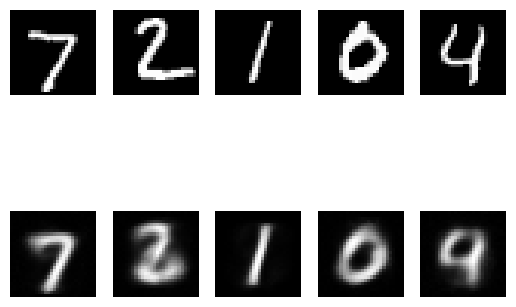

In [ ]:
import keras
from keras import datasets
from keras.models import Model
from keras.layers import Input, Dense, Dropout
from keras import regularizers
import matplotlib.pyplot as plt

# load data
(x_train, _), (x_test, _) = datasets.mnist.load_data()

x_train = x_train/255.0
x_test = x_test/255.0

x_train = x_train.reshape(-1,784)
x_test = x_test.reshape(-1,784)

# model
input_img = Input(shape=(784,))

# ✅ regularization added here
encoded = Dense(128, activation='relu',
                activity_regularizer=regularizers.l1(1e-5))(input_img)

encoded = Dropout(0.3)(encoded)

decoded = Dense(784, activation='sigmoid')(encoded)

model = Model(input_img, decoded)

model.compile(optimizer='adam', loss='binary_crossentropy')

model.fit(x_train, x_train, epochs=3, batch_size=256)

# predict
decoded_imgs = model.predict(x_test[:5])

# show images
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    plt.subplot(2,5,i+6)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

Q7. Implement denoising AE

Epoch 1/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.2663
Epoch 2/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.1760
Epoch 3/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1492
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


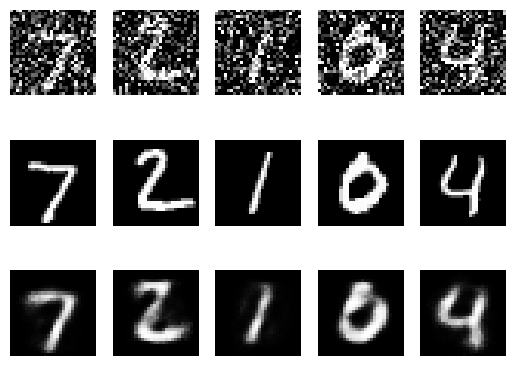

In [ ]:
import keras
from keras import datasets
from keras.models import Model
from keras.layers import Input, Dense
import numpy as np
import matplotlib.pyplot as plt

# load data
(x_train, _), (x_test, _) = datasets.mnist.load_data()

x_train = x_train/255.0
x_test = x_test/255.0

x_train = x_train.reshape(-1,784)
x_test = x_test.reshape(-1,784)

# 🔥 add noise
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

# keep values between 0 and 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# model
input_img = Input(shape=(784,))
encoded = Dense(64, activation='relu')(input_img)
decoded = Dense(784, activation='sigmoid')(encoded)

model = Model(input_img, decoded)
model.compile(optimizer='adam', loss='binary_crossentropy')

# 🔥 train (noisy → clean)
model.fit(x_train_noisy, x_train, epochs=3, batch_size=256)

# predict
decoded_imgs = model.predict(x_test_noisy[:5])

# show results
for i in range(5):
    # noisy input
    plt.subplot(3,5,i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    # clean original
    plt.subplot(3,5,i+6)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    # reconstructed
    plt.subplot(3,5,i+11)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

Q8. PCA with AE on MNIST

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


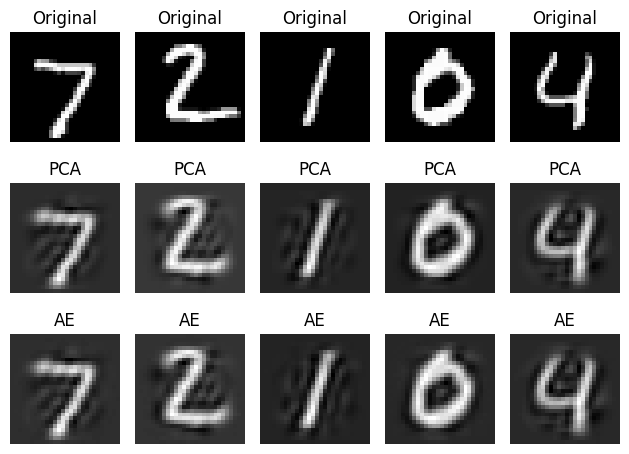

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from keras.datasets import mnist
from keras.layers import Input, Dense
from keras.models import Model

# data
(x_train,_),(x_test,_) = mnist.load_data()

# preprocess
x_train = x_train.reshape(-1,784)/255
x_test  = x_test.reshape(-1,784)/255

# 🔹 PCA (fit on train, transform test)
pca = PCA(64)
pca.fit(x_train)

x_pca = pca.transform(x_test)
x_pca_recon = pca.inverse_transform(x_pca)

# 🔹 Autoencoder
inp = Input(shape=(784,))
x = Dense(64, activation='linear')(inp)   # correct (linear AE)
out = Dense(784, activation='linear')(x)
ae = Model(inp,out)

ae.compile('adam','mse')

# train on TRAIN data (not test)
ae.fit(x_train, x_train, epochs=10, batch_size=256, verbose=0)   # FIXED

# predict on test samples
x_ae = ae.predict(x_test[:5])

# show results
for i in range(5):
    # Original
    plt.subplot(3,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # PCA
    plt.subplot(3,5,i+6)
    plt.imshow(x_pca_recon[i].reshape(28,28), cmap='gray')
    plt.title("PCA")
    plt.axis('off')

    # AE
    plt.subplot(3,5,i+11)
    plt.imshow(x_ae[i].reshape(28,28), cmap='gray')
    plt.title("AE")
    plt.axis('off')

plt.tight_layout()
plt.show()

Q9. a. sparse AE

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.3842
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2486
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.2238
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.2115
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2038
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


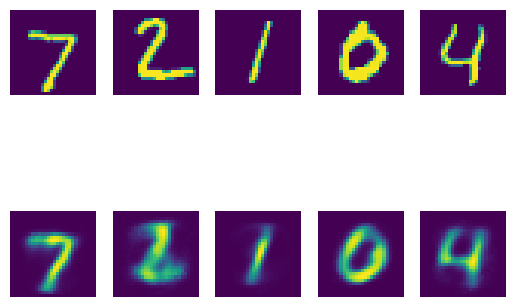

In [ ]:
import keras, matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.layers import Input, Dense
from keras.models import Model
from keras import regularizers

# data
(x_train,_),(x_test,_) = mnist.load_data()
x_train = x_train.reshape(-1,784)/255
x_test  = x_test.reshape(-1,784)/255

# model (minimal fix)
inp = Input(shape=(784,))
x = Dense(128, activation='relu')(inp)
x = Dense(64, activation='relu',
          activity_regularizer=regularizers.l1(1e-5))(x)   # sparsity here
out = Dense(784, activation='sigmoid')(x)

model = Model(inp,out)

model.compile('adam','binary_crossentropy')
model.fit(x_train,x_train,epochs=5,batch_size=256)

# predict
res = model.predict(x_test[:5])

# show
for i in range(5):
    plt.subplot(2,5,i+1); plt.imshow(x_test[i].reshape(28,28)); plt.axis('off')
    plt.subplot(2,5,i+6); plt.imshow(res[i].reshape(28,28)); plt.axis('off')
plt.show()

Q9. b. Contractive AE

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0667
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0345
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0274
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0228
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0196
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
(5, 784)


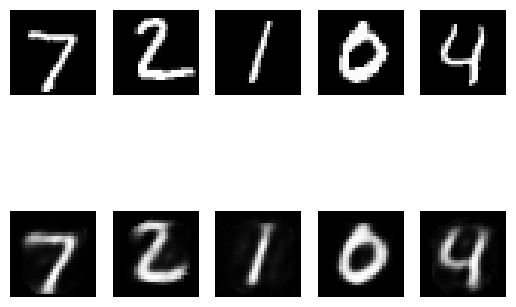

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
# data
(x_train,_),(x_test,_) = mnist.load_data()
x_train = x_train.reshape(-1,784)/255.0
x_test  = x_test.reshape(-1,784)/255.0

# model
inp = Input(shape=(784,))
hidden = Dense(64, activation='relu')(inp)
out = Dense(784, activation='sigmoid')(hidden)
model = Model(inp, out)

lambda_c = 1e-4

# simplified contractive loss
def loss_fn(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))

    W = model.layers[1].kernel   # hidden layer weights
    contractive = tf.reduce_sum(tf.square(W))

    return mse + lambda_c * contractive

model.compile(optimizer='adam', loss=loss_fn)

# train
model.fit(x_train, x_train, epochs=5, batch_size=256)

# test
res = model.predict(x_test[:5])
print(res.shape)

#visualization

for i in range(5):
    # original image
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    # reconstructed image
    plt.subplot(2,5,i+6)
    plt.imshow(res[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

Q10. RNN for next character prediction

In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense
from keras.utils import to_categorical

text = "hello world"
chars = sorted(set(text))

c2i = {c:i for i,c in enumerate(chars)}
i2c = {i:c for c,i in c2i.items()}

seq_len = 3

# data
X, y = [], []
for i in range(len(text)-seq_len):
    X.append([c2i[c] for c in text[i:i+seq_len]])
    y.append(c2i[text[i+seq_len]])

X = to_categorical(X, num_classes=len(chars))
y = to_categorical(y, num_classes=len(chars))

# model
model = Sequential([
    SimpleRNN(32, input_shape=(seq_len, len(chars))),
    Dense(len(chars), activation='softmax')
])

model.compile('adam','categorical_crossentropy')
model.fit(X, y, epochs=200, verbose=0)

# predict
def predict_next(seq):
    x = to_categorical([[c2i[c] for c in seq]], num_classes=len(chars))
    return i2c[np.argmax(model.predict(x, verbose=0))]

print("Next char:", predict_next("hel"))

Next char: l


Q11. BERT model for sentimemnt analysis

In [ ]:
# install (only if needed)
!pip install -q transformers

from transformers import pipeline

# load BERT-based sentiment model
classifier = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

# input
text = "I love this product!"

# predict
result = classifier(text)[0]

# binary output
binary_output = 1 if result['label'] == "POSITIVE" else 0

print("Text:", text)
print("Model Output:", result)
print("Binary:", binary_output)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Text: I love this product!
Model Output: {'label': 'POSITIVE', 'score': 0.9998855590820312}
Binary: 1


Q12. GAN on MNIST

In [ ]:
import tensorflow as tf
import numpy as np

# data
(x_train,_),_ = tf.keras.datasets.mnist.load_data()
x_train = x_train.reshape(-1,784)/255.0

# generator
generator = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_dim=100),
    tf.keras.layers.Dense(784, activation='sigmoid')
])

# discriminator
discriminator = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_dim=784),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

discriminator.compile('adam','binary_crossentropy')

# GAN
discriminator.trainable = False
z = tf.keras.Input(shape=(100,))
gan = tf.keras.Model(z, discriminator(generator(z)))
gan.compile('adam','binary_crossentropy')

# training (minimal)
for _ in range(500):
    idx = np.random.randint(0, x_train.shape[0], 32)
    real = x_train[idx]

    noise = np.random.normal(0,1,(32,100))
    fake = generator.predict(noise, verbose=0)

    discriminator.trainable = True
    discriminator.train_on_batch(real, np.ones((32,1)))
    discriminator.train_on_batch(fake, np.zeros((32,1)))

    discriminator.trainable = False
    gan.train_on_batch(noise, np.ones((32,1)))

# generate sample
img = generator.predict(np.random.normal(0,1,(1,100)))
print(img.shape)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
(1, 784)
